## Setting up PySpark

In [3]:
import os
import sys

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

from pyspark.sql import SparkSession

# Creating Spark session with more memory for large dataset
spark = SparkSession.builder \
    .appName("FlightDelaysPipeline") \
    .config("spark.driver.host", "127.0.0.1") \ # binding driver to local adress
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.memory", "8g") \ # 8GB of RAM - we have a big dataset
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark session created.")

Spark version: 3.5.3
Spark session created.


## Loading data

In [5]:
# Loading the datasets
df_flights = spark.read.csv("flights.csv", header=True, inferSchema=True)
df_airlines = spark.read.csv("airlines.csv", header=True, inferSchema=True)
df_airports = spark.read.csv("airports.csv", header=True, inferSchema=True)

# Checking basic info
print(f"Flights: {df_flights.count()} rows, {len(df_flights.columns)} columns")
print(f"Airlines: {df_airlines.count()} rows")
print(f"Airports: {df_airports.count()} rows")

Flights: 5819079 rows, 31 columns
Airlines: 14 rows
Airports: 322 rows


In [6]:
# Checking schema - column names and data types
print("Flights schema:")
df_flights.printSchema()

Flights schema:
root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- FLIGHT_NUMBER: integer (nullable = true)
 |-- TAIL_NUMBER: string (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DESTINATION_AIRPORT: string (nullable = true)
 |-- SCHEDULED_DEPARTURE: integer (nullable = true)
 |-- DEPARTURE_TIME: integer (nullable = true)
 |-- DEPARTURE_DELAY: integer (nullable = true)
 |-- TAXI_OUT: integer (nullable = true)
 |-- WHEELS_OFF: integer (nullable = true)
 |-- SCHEDULED_TIME: integer (nullable = true)
 |-- ELAPSED_TIME: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- WHEELS_ON: integer (nullable = true)
 |-- TAXI_IN: integer (nullable = true)
 |-- SCHEDULED_ARRIVAL: integer (nullable = true)
 |-- ARRIVAL_TIME: integer (nullable = true)
 |-- ARRIVAL_DELA

In [7]:
# Preview first 5 rows
df_flights.show(5)

+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+--------------+---------------+--------+----------+--------------+------------+--------+--------+---------+-------+-----------------+------------+-------------+--------+---------+-------------------+----------------+--------------+-------------+-------------------+-------------+
|YEAR|MONTH|DAY|DAY_OF_WEEK|AIRLINE|FLIGHT_NUMBER|TAIL_NUMBER|ORIGIN_AIRPORT|DESTINATION_AIRPORT|SCHEDULED_DEPARTURE|DEPARTURE_TIME|DEPARTURE_DELAY|TAXI_OUT|WHEELS_OFF|SCHEDULED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|WHEELS_ON|TAXI_IN|SCHEDULED_ARRIVAL|ARRIVAL_TIME|ARRIVAL_DELAY|DIVERTED|CANCELLED|CANCELLATION_REASON|AIR_SYSTEM_DELAY|SECURITY_DELAY|AIRLINE_DELAY|LATE_AIRCRAFT_DELAY|WEATHER_DELAY|
+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+--------------+---------------+--------+----------+--------------+------------+--------+-

Missing values

In [8]:
from pyspark.sql import functions as F

# Checking missing values for key columns
print("Missing values in key columns:")
key_columns = ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "CANCELLED", "CANCELLATION_REASON",
               "WEATHER_DELAY", "AIRLINE_DELAY", "AIR_SYSTEM_DELAY"]

for col in key_columns:
    missing = df_flights.filter(F.col(col).isNull()).count()
    total = df_flights.count()
    print(f"  {col}: {missing} ({missing/total*100:.1f}%)")

Missing values in key columns:
  DEPARTURE_DELAY: 86153 (1.5%)
  ARRIVAL_DELAY: 105071 (1.8%)
  CANCELLED: 0 (0.0%)
  CANCELLATION_REASON: 5729195 (98.5%)
  WEATHER_DELAY: 4755640 (81.7%)
  AIRLINE_DELAY: 4755640 (81.7%)
  AIR_SYSTEM_DELAY: 4755640 (81.7%)


Cleaning the data

In [10]:
# Data cleaning pipeline
# Step 1: removing cancelled flights (no departure/arrival delay)
df_clean = df_flights.filter(F.col("CANCELLED") == 0)

In [11]:
# Step 2: removing rows with missing departure or arrival delay
df_clean = df_clean.filter(
    F.col("DEPARTURE_DELAY").isNotNull() &
    F.col("ARRIVAL_DELAY").isNotNull()
)

In [12]:
# Step 3: filling missing delay cause columns with 0 (no delay from that cause)
delay_columns = ["WEATHER_DELAY", "AIRLINE_DELAY", "AIR_SYSTEM_DELAY",
                 "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"]

for col in delay_columns:
    df_clean = df_clean.fillna({col: 0})

print(f"Rows before cleaning: {df_flights.count()}")
print(f"Rows after cleaning: {df_clean.count()}")

Rows before cleaning: 5819079
Rows after cleaning: 5714008


## Feature engineering

__Adding new columns__

In [13]:
# Step 1: adding a column indicating whether the flight was delayed (arrival delay > 15 min)
df_clean = df_clean.withColumn(
    "IS_DELAYED",
    F.when(F.col("ARRIVAL_DELAY") > 15, 1).otherwise(0)
)

In [14]:
# Step 2: adding delay category
df_clean = df_clean.withColumn(
    "DELAY_CATEGORY",
    F.when(F.col("ARRIVAL_DELAY") <= 0, "on_time")
     .when(F.col("ARRIVAL_DELAY") <= 15, "minor_delay")
     .when(F.col("ARRIVAL_DELAY") <= 60, "moderate_delay")
     .otherwise("severe_delay")
)

In [33]:
# Step 3: adding season column
df_clean = df_clean.withColumn(
    "SEASON",
    F.when(F.col("MONTH").isin(12, 1, 2), "winter")
    .when(F.col("MONTH").isin(3, 4, 5), "spring")
    .when(F.col("MONTH").isin(6, 7, 8), "summer")
    .otherwise("autumn")
)

print("New columns added.")
df_clean.select("ARRIVAL_DELAY", "IS_DELAYED", "DELAY_CATEGORY", "SEASON").show(5)

New columns added.
+-------------+----------+--------------+------+
|ARRIVAL_DELAY|IS_DELAYED|DELAY_CATEGORY|SEASON|
+-------------+----------+--------------+------+
|          -22|         0|       on_time|winter|
|           -9|         0|       on_time|winter|
|            5|         0|   minor_delay|winter|
|           -9|         0|       on_time|winter|
|          -21|         0|       on_time|winter|
+-------------+----------+--------------+------+
only showing top 5 rows



## Analysis

In [19]:
# Registering cleaned DataFrame as SQL table
df_clean.createOrReplaceTempView("flights") # we can use this table for SQL queries later

# Analysis 1: delay statistics by airline
airline_stats = spark.sql("""
    SELECT 
        AIRLINE,
        COUNT(*) AS total_flights,
        ROUND(AVG(ARRIVAL_DELAY), 2) AS avg_delay_min,
        SUM(IS_DELAYED) AS delayed_flights,
        ROUND(SUM(IS_DELAYED) / COUNT(*) * 100, 1) AS delay_rate_pct
    FROM flights
    GROUP BY AIRLINE
    ORDER BY delay_rate_pct DESC
""")

airline_stats.show()

+-------+-------------+-------------+---------------+--------------+
|AIRLINE|total_flights|avg_delay_min|delayed_flights|delay_rate_pct|
+-------+-------------+-------------+---------------+--------------+
|     NK|       115193|        14.47|          33166|          28.8|
|     F9|        90090|         12.5|          22851|          25.4|
|     B6|       262042|         6.68|          57257|          21.9|
|     MQ|       278791|         6.46|          58623|          21.0|
|     UA|       507762|         5.43|         101303|          20.0|
|     EV|       554752|         6.59|         105331|          19.0|
|     VX|        61248|         4.74|          11348|          18.5|
|     WN|      1242403|         4.37|         227317|          18.3|
|     OO|       576814|         5.85|         103850|          18.0|
|     US|       194223|         3.71|          34930|          18.0|
|     AA|       712935|         3.45|         125238|          17.6|
|     DL|       870275|         0.

In [20]:
# Analysis 2: delay rate by season
season_stats = spark.sql("""
	SELECT
		SEASON,
		COUNT(*) AS total_flights,
		ROUND(AVG(ARRIVAL_DELAY), 2) AS avg_delay_min,
		ROUND(SUM(IS_DELAYED) / COUNT(*) * 100, 1) AS delay_rate_pct
	FROM flights
	GROUP BY SEASON
	ORDER BY delay_rate_pct DESC
""")

season_stats.show()

+------+-------------+-------------+--------------+
|SEASON|total_flights|avg_delay_min|delay_rate_pct|
+------+-------------+-------------+--------------+
|winter|      1334393|         6.68|          20.8|
|summer|      1511187|         6.86|          20.3|
|spring|      1461030|          4.2|          17.6|
|autumn|      1407398|        -0.16|          13.0|
+------+-------------+-------------+--------------+



In [21]:
# Analysis 3: top 10 worst airports by delay rate
airport_stats = spark.sql("""
	SELECT
		ORIGIN_AIRPORT,
		COUNT(*) AS total_flights,
		ROUND(AVG(ARRIVAL_DELAY), 2) AS avg_delay_min,
		ROUND(SUM(IS_DELAYED) / COUNT(*) * 100, 1) AS delay_rate_pct
	FROM flights
	GROUP BY ORIGIN_AIRPORT
	HAVING COUNT(*) > 10000
	ORDER BY delay_rate_pct DESC
	LIMIT 10
""")

airport_stats.show()

+--------------+-------------+-------------+--------------+
|ORIGIN_AIRPORT|total_flights|avg_delay_min|delay_rate_pct|
+--------------+-------------+-------------+--------------+
|           ORD|       276554|          8.6|          23.4|
|           LGA|        94834|         5.63|          23.2|
|           MIA|        68301|         7.04|          22.4|
|           BWI|        84329|         7.25|          21.7|
|           DEN|       193402|         7.19|          21.6|
|           DAL|        58672|         7.99|          21.5|
|           JFK|        91663|         3.61|          21.4|
|           MDW|        78685|         6.05|          21.2|
|           PBI|        22134|         7.94|          21.1|
|           PHL|        64751|         4.39|          21.1|
+--------------+-------------+-------------+--------------+



Joining tables

In [23]:
# Joining flights with airlines and airports to get full names
df_airlines_renamed = df_airlines.withColumnRenamed("IATA_CODE", "AIRLINE_CODE") \
	.withColumnRenamed("AIRLINE", "AIRLINE_NAME")

df_airports_renamed = df_airports.withColumnRenamed("IATA_CODE", "AIRPORT_CODE") \
	.withColumnRenamed("AIRPORT", "AIRPORT_NAME")

# Joining flights with airline names
df_joined = df_clean.join(
	df_airlines_renamed,
	df_clean["AIRLINE"] == df_airlines_renamed["AIRLINE_CODE"], # condition for join
	"left"
)

# Joining with airport names
df_joined = df_joined.join(
	df_airports_renamed,
	df_joined["ORIGIN_AIRPORT"] == df_airports_renamed["AIRPORT_CODE"],
	"left"
)

print("Join completed.")
df_joined.select("AIRLINE_NAME", "AIRPORT_NAME", "ARRIVAL_DELAY", "DELAY_CATEGORY").show(5)

Join completed.
+--------------------+--------------------+-------------+--------------+
|        AIRLINE_NAME|        AIRPORT_NAME|ARRIVAL_DELAY|DELAY_CATEGORY|
+--------------------+--------------------+-------------+--------------+
|Alaska Airlines Inc.|Ted Stevens Ancho...|          -22|       on_time|
|American Airlines...|Los Angeles Inter...|           -9|       on_time|
|     US Airways Inc.|San Francisco Int...|            5|   minor_delay|
|American Airlines...|Los Angeles Inter...|           -9|       on_time|
|Alaska Airlines Inc.|Seattle-Tacoma In...|          -21|       on_time|
+--------------------+--------------------+-------------+--------------+
only showing top 5 rows



In [24]:
# Registering joined DataFrame as SQL table
df_joined.createOrReplaceTempView("flights_full")

# Top 10 airlines by delay rate with full names
spark.sql("""
	SELECT
		AIRLINE_NAME,
		COUNT(*) AS total_flights,
		ROUND(AVG(ARRIVAL_DELAY), 2) AS avg_delay_min,
		ROUND(SUM(IS_DELAYED) / COUNT(*) * 100, 1) AS delay_rate_pct
	FROM flights_full
	GROUP BY AIRLINE_NAME
	ORDER BY delay_rate_pct DESC
""").show(truncate=False) # we want to see the full names of airlines

+----------------------------+-------------+-------------+--------------+
|AIRLINE_NAME                |total_flights|avg_delay_min|delay_rate_pct|
+----------------------------+-------------+-------------+--------------+
|Spirit Air Lines            |115193       |14.47        |28.8          |
|Frontier Airlines Inc.      |90090        |12.5         |25.4          |
|JetBlue Airways             |262042       |6.68         |21.9          |
|American Eagle Airlines Inc.|278791       |6.46         |21.0          |
|United Air Lines Inc.       |507762       |5.43         |20.0          |
|Atlantic Southeast Airlines |554752       |6.59         |19.0          |
|Virgin America              |61248        |4.74         |18.5          |
|Southwest Airlines Co.      |1242403      |4.37         |18.3          |
|Skywest Airlines Inc.       |576814       |5.85         |18.0          |
|US Airways Inc.             |194223       |3.71         |18.0          |
|American Airlines Inc.      |712935  

## Visualization

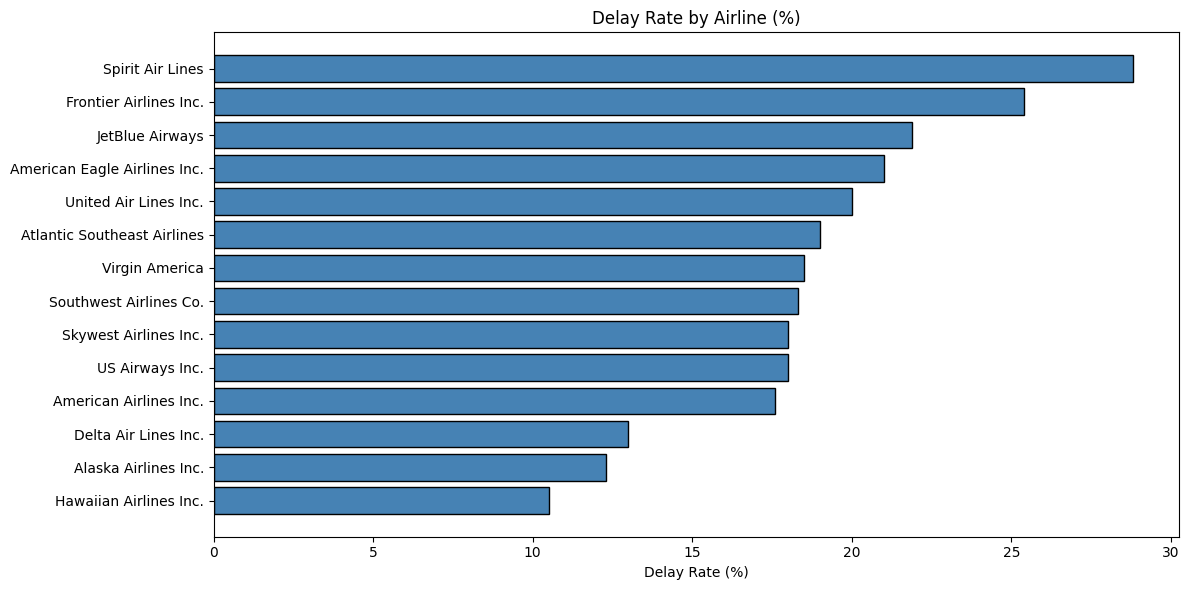

In [27]:
# Delay rate by airline
plt.figure(figsize=(12, 6))
plt.barh(airline_pd["AIRLINE_NAME"], airline_pd["delay_rate_pct"],
         color="steelblue", edgecolor="black")
plt.title("Delay Rate by Airline (%)")
plt.xlabel("Delay Rate (%)")
plt.gca().invert_yaxis() # gca = "get current axes" - needed for the inversion (DESC)
plt.tight_layout()
plt.show()

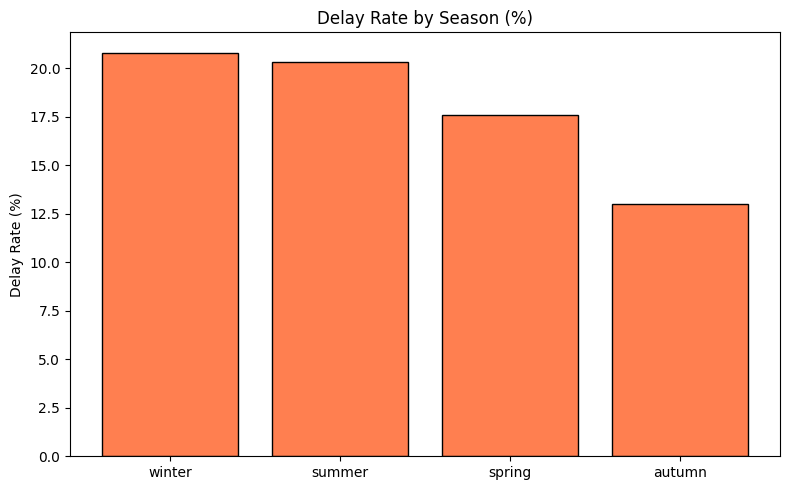

In [32]:
# Delay rate by season
plt.figure(figsize=(8, 5))
plt.bar(season_pd["SEASON"], season_pd["delay_rate_pct"], color="coral",
        edgecolor="black")
plt.title("Delay Rate by Season (%)")
plt.ylabel("Delay Rate (%)")
plt.tight_layout()
plt.show()

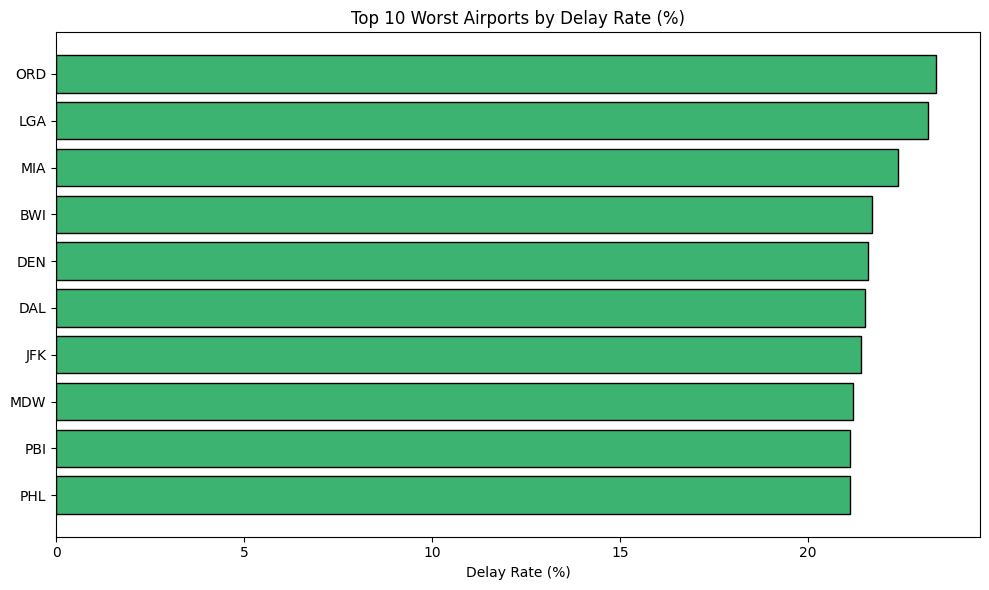

In [31]:
# Top 10 worst airports by delay rate
plt.figure(figsize=(10, 6))
plt.barh(airport_pd["ORIGIN_AIRPORT"], airport_pd["delay_rate_pct"],
         color="mediumseagreen", edgecolor="black")
plt.title("Top 10 Worst Airports by Delay Rate (%)")
plt.xlabel("Delay Rate (%)")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

## Pipeline Summary

**Dataset:** 5819079 flights from 2015 (USA)

**Pipeline steps:**
1. Data "ingestion" - loading flights, airlines and airports CSV files
2. Data cleaning - removed cancelled flights and missing values (5714008 rows remaining)
3. Feature engineering - added IS_DELAYED, DELAY_CATEGORY and SEASON columns
4. Spark SQL analysis - delay statistics by airline, season and airport
5. Table joins - connected flight codes with full airline and airport names
6. Visualization - delay patterns across airlines, seasons and airports

**Key findings:**
- Spirit Airlines worst delay rate: 28.8%
- Alaska Airlines best: 12.3% (average arrival -0.98 min ahead of schedule)
- Winter and summer worst seasons (20%+ delay rate)
- Chicago O'Hare (ORD) worst airport: 23.4% delay rate